# **AN EXAMPLE OF CORRELATED STOCK RETURNS**

*In this lesson, we will guide you through the process of generating correlated stock returns with the GBM process, using real data obtained from past returns' distributions and a correlation matrix.*

*This is going to be a very helpful tool when it comes to pricing, for example, a basket option.*

- **What is a Basket Option?** → In short, an option whose payoff depends on the evolution of several underlying assets. More [here](https://en.wikipedia.org/wiki/Basket_option).


As always, let's start by importing the necessary libraries:

In [1]:
# Import libraries
%matplotlib inline
from math import exp, sqrt
import matplotlib.pyplot as plt
import numpy as np

## 1. Gathering Historical Data on Stock Returns' Distribution and Correlations

In order to simulate correlated stock price paths under the GBM process, we need some input parameters: volatility and correlation matrix. 
One possibility is to obtain these parameters from the distribution of past returns. Thus, our first step is to get this data. For illustrative purposes, we are going to use the parameters based on past historical returns of Apple, Amazon, Facebook/Meta, Google/Alphabet, and Microsoft. 

In [2]:
import pandas as pd

file_paths = {
    'AAPL': 'AAPL_wqu_data.csv',
    'AMZN': 'AMZN_wqu_data.csv',
    'FB': 'FB_wqu_data.csv',
    'GOOG': 'GOOG_wqu_data.csv',
    'MSFT': 'MSFT_wqu_data.csv',
}

# Load adjusted close prices
df_prices = {}

for ticker, path in file_paths.items():
    df = pd.read_csv(path, parse_dates=['timestamp'])
    df.set_index('timestamp', inplace=True)
    df_prices[ticker] = df['close']

# Combine into one DataFrame
df_tickers = pd.concat(df_prices.values(), axis=1)
df_tickers.columns = df_prices.keys()

# Drop rows with any NaNs to ensure all tickers have data
# This forces the DataFrame to start from the first common available date
df_tickers = df_tickers.dropna()
df_tickers.head()

,AAPL,AMZN,FB,GOOG,MSFT
timestamp,,,,,
2012-05-18 04:00:00,18.9421,10.6925,38.2318,30.0200,29.27
2012-05-21 04:00:00,20.0457,10.9055,34.0300,30.7055,29.75
2012-05-22 04:00:00,19.8918,10.7665,31.0000,30.0400,29.76
2012-05-23 04:00:00,20.3771,10.8640,32.0000,30.4730,29.11
2012-05-24 04:00:00,20.1900,10.7620,33.0300,30.1830,29.07


Next, we calculate the daily returns, volatilities, and correlation matrix of returns:

In [3]:
df_tickers_ret = df_tickers / df_tickers.shift(1) - 1
volatility = (
    df_tickers_ret.std()
)  # This is daily volatility, we will later on annualize it!
df_tickers_corr = df_tickers_ret.corr()
print(df_tickers_corr)

          AAPL      AMZN        FB      GOOG      MSFT
AAPL  1.000000  0.475788  0.417885  0.466287  0.591477
AMZN  0.475788  1.000000  0.475429  0.531200  0.568306
FB    0.417885  0.475429  1.000000  0.467765  0.440463
GOOG  0.466287  0.531200  0.467765  1.000000  0.571181
MSFT  0.591477  0.568306  0.440463  0.571181  1.000000


## 2. Cholesky Decomposition

In the next step, we use Cholesky factorization in order to simulate our multivariate correlated normal variables ($\epsilon$ from slides).

For that, we make use of the numpy method `np.linalg.cholesky()`, which facilitates the task.

In [4]:
# Perform Cholesky decomposition on coefficient matrix
R = np.linalg.cholesky(df_tickers_corr)

# Compute transpose conjugate (only for validation)
RT = R.T.conj()

# Compare the R matrix and check the reconstruction of the original correlation matrix:
# 1. R  matrix from Cholesky decomposition
print("This is the R matrix: ")
print(R)
# 2. Reconstruct coefficient matrix from factorization (only for validation)
print("This is the reconstructed original correlation matrix ")
print(np.dot(R, RT))

This is the R matrix: 
[[1.         0.         0.         0.         0.        ]
 [0.47578823 0.87955987 0.         0.         0.        ]
 [0.41788466 0.31447993 0.8523349  0.         0.        ]
 [0.46628677 0.35170587 0.19042583 0.78906124 0.        ]
 [0.59147748 0.3261724  0.10643608 0.20327653 0.70079667]]
This is the reconstructed original correlation matrix 
[[1.         0.47578823 0.41788466 0.46628677 0.59147748]
 [0.47578823 1.         0.47542852 0.53120012 0.56830618]
 [0.41788466 0.47542852 1.         0.46776511 0.44046322]
 [0.46628677 0.53120012 0.46776511 1.         0.57118068]
 [0.59147748 0.56830618 0.44046322 0.57118068 1.        ]]


## 3. Simulate

Now, it is the time to make use of Cholesky decomposition in the previous point, and stock return volatility data to actually simulate the price paths for different assets taking into account the dynamics of the mentioned firms.

Remember, we do not really care about the $\mu$ parameter since we are in a risk-neutral world.

In [5]:
T = 252
Num = len(volatility)  # Number of simulated days
stock_price_array = np.full(
    (Num, T), 100.0
)  # Stock price, first value is simulation input
volatility_array = volatility * sqrt(252)  # Volatility (annual, 0.01=1%)
r = 0.001  # Risk-free rate (annual, 0.01=1%)
dt = 1.0 / T  # Time increment (annualized)

For comparability purposes, let's assume that $S_0=100$ for all of our different stocks simulated (obviously, this will change in real life for a basket option):

In [6]:
stock_price_array

array([[100., 100., 100., ..., 100., 100., 100.],
       [100., 100., 100., ..., 100., 100., 100.],
       [100., 100., 100., ..., 100., 100., 100.],
       [100., 100., 100., ..., 100., 100., 100.],
       [100., 100., 100., ..., 100., 100., 100.]])

With all the previous inputs, we can now simulate price paths using the "classic" price process:

$$
\begin{equation}
S_t = S_{t-1} e^{\left(\left(r - \frac{\sigma^2}{2}\right)dt + \sigma ϵ \sqrt{dt}\right)}
\end{equation}
$$

In [7]:
for t in range(1, T):
    # Generate array of random standard normal draws
    random_array = np.random.standard_normal(Num)

    # Multiply R (from factorization) with random_array to obtain correlated epsilons
    epsilon_array = np.inner(random_array, R)

    # Sample price path per stock
    for n in range(Num):
        dt = 1 / T
        S = stock_price_array[n, t - 1]
        v = volatility_array[n]
        epsilon = epsilon_array[n]

        # Generate new stock price
        stock_price_array[n, t] = S * exp(
            (r - 0.5 * v**2) * dt + v * sqrt(dt) * epsilon
        )

Finally, we can plot the paths:<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

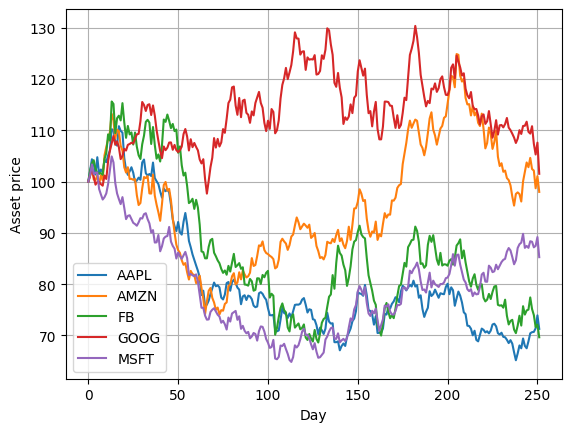

In [17]:
# Plot simulated price paths
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
array_day_plot = [t for t in range(T)]
tickers = df_tickers.columns

for n in range(Num):
    ax.plot(array_day_plot, stock_price_array[n], label="{}".format(tickers[n]))

plt.grid()
plt.xlabel("Day")
plt.ylabel("Asset price")
plt.legend(loc="best")

plt.show()

## 4. Conclusion

Well done! Now you have learned how to use Cholesky's decomposition in order to be able to simulate price paths for a number of assets. In the next module, we will move forward in our understanding of derivative pricing by incorporating more complex pricing models where, for example, we start considering the case of a non-constant volatility parameter. 